In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("onlinefraud_clean.csv")

In [3]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [4]:
df["isFraud"].value_counts()

0    6354407
1       8213
Name: isFraud, dtype: int64

In [5]:
# Fraus percentage
(df["isFraud"].value_counts(normalize=True) * 100).round(2)

0    99.87
1     0.13
Name: isFraud, dtype: float64

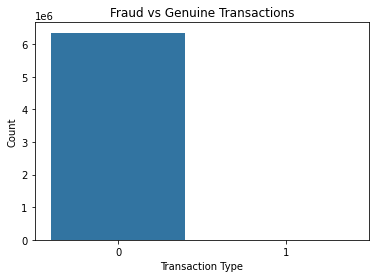

In [6]:
# Plot fraud distribution
plt.figure(figsize=(6,4))

sns.countplot(x="isFraud", data=df)

plt.title("Fraud vs Genuine Transactions")
plt.xlabel("Transaction Type")
plt.ylabel("Count")

plt.show()

In [7]:
# Payment Type Distribution
df["type"].value_counts()

CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: type, dtype: int64

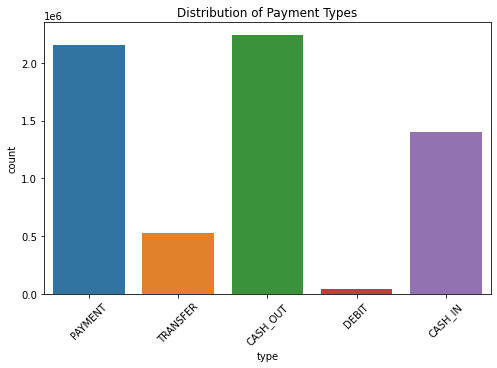

In [8]:
# Visualize Payment Type
plt.figure(figsize=(8,5))

sns.countplot(x="type", data=df)

plt.title("Distribution of Payment Types")
plt.xticks(rotation=45)

plt.show()

In [10]:
pd.crosstab(df["type"], df["isFraud"])

isFraud,0,1
type,,
CASH_IN,1399284,0
CASH_OUT,2233384,4116
DEBIT,41432,0
PAYMENT,2151495,0
TRANSFER,528812,4097


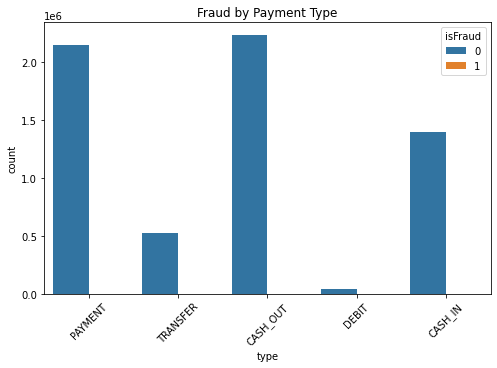

In [11]:
plt.figure(figsize=(8,5))

sns.countplot(x="type", hue="isFraud", data=df)

plt.title("Fraud by Payment Type")
plt.xticks(rotation=45)

plt.show()

In [12]:
# Analyze Transaction Amount
df["amount"].describe()

count    6.362620e+06
mean     1.798619e+05
std      6.038582e+05
min      0.000000e+00
25%      1.338957e+04
50%      7.487194e+04
75%      2.087215e+05
max      9.244552e+07
Name: amount, dtype: float64

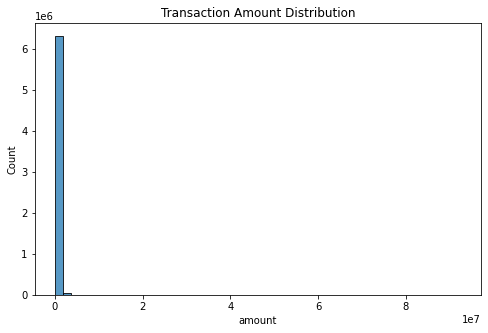

In [13]:
# Plot Transation Amount
plt.figure(figsize=(8,5))

sns.histplot(df["amount"], bins=50)

plt.title("Transaction Amount Distribution")

plt.show()

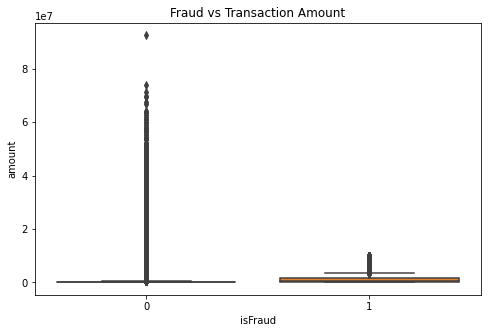

In [14]:
# Fraud Amount Comparison
plt.figure(figsize=(8,5))

sns.boxplot(x="isFraud", y="amount", data=df)

plt.title("Fraud vs Transaction Amount")

plt.show()

In [16]:
# Average transaction amount
df.groupby("isFraud")["amount"].mean()

isFraud
0    1.781970e+05
1    1.467967e+06
Name: amount, dtype: float64